In [89]:
# Add directory above current directory to path
import sys as SYS; SYS.path.insert(0, '..'); SYS.path.insert(0, '../..')
import csv
from Scripts import simulation_CLI as cleo
from Scripts import hdf5merge
import h5py
import matplotlib.pyplot as plt
import numpy as np
from src import density_matrix as DM
from src import circuit_architecture
from scipy import stats
from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec

## Run simulation

In [90]:
with open('../../non_markovian_orders_list/rule_0_0_2_2.csv', 'r') as f:
    reader = csv.reader(f)
    NM_list_skewed = [row[0].strip() for row in reader if row and row[0].strip()]
NM_list_skewed
NM_list_skewed[0]

'jjgggjggjggjjgggggjggjjgggggggjjggjggjjggjjggjggjgjjgggjjgggjgggjggjgggggjgggjjggggggjgggggjjggjggggjggggjggjgjjggjjggjggjjggjggggjjggjggjjggjggjggggjggggggjjggjjggjgggjggggjjggjjggjjggjjggjjgggggjjgggjgjjggjggggjjgggggjggjggjggjjgggjggggggjgggjgggjggggggjggjggjjgggjgggjggjggggjjggjggjggjjggjjggggjggjjgggjgggggggjggjggjjggjjggjjggggggjjgggjgjggjgggjjgggjgggjggjjgggjgggjggggggjjggjjggjgggjjggjjgggjjgggjjggjgggjjggjgggjggjgjgjggjggggjjggjjggjjggggjjgggjjggjjggjgjgggggjggjjgggjggggjggjjggjggjggggjjgg'

In [91]:
Trials =10
NM_list_skewed=["jgggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggjggg"
,"jgjgggggggggjggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggjgggggjgggggggggggggggggg"
,"jgggggggggggggggggggggggggjgggggggjjjgggggjggggggggggggggggggggggggggggggggggggggggggggggggggggggggg"
,"jgggggggggggggggggggggggggggggggjgggggggggggggggggggggggggggggggggggggggggggggggggggggggggjggggggggg"
,"jgggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggjggggggggggggggggggggggggg"
,"jggggggggggggggggggggggggggggggggggggggggggggggggggggjgggggggggggggggggggggggggggggggggggggggggggggg"
,"jggggggggggggggggggjgggjgggggggggggggggggggggggggggjgggggggggggggggggggggggggggggggggggggggggggggggg"
,"jggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggggjgjggggggggggjgggjggg"
,"jggjggggggggggggggggggggggggggggggggggggggggggjgggggggggggggggggjggggggggggggggggggggggggggggggggggg"
,"jgggggggggggggggggggggggggggggggggggggggggggggggggjggggggggggggggggggggggjgggggggggggggggggggggjgjgg"]
for unitary_seed in range(Trials):
    #initial_pops = [0.043407, 0.12, 0.09, 0.15, 0.3,0.14, 0.23, 0.026593]
    #initial_pops = [0,0,0,0,1,0,0,0]
    NM_orders_list = NM_list_skewed[unitary_seed]
    initial_pops = [0.1,0.1,0.1,0.1,0.4,0.1,0.1,0.1]
    system = DM.n_thermal_qbits(initial_pops)
    connectivity = "c2_2local"
    unitary_energy_subspace = 1
    ordering_seed = 1
    chunk_size = 2
    order_rule_name = "NonMarkovian"
    num_steps = 100
    name_for_saving = f"{unitary_seed}"
    data = cleo.execute(file_name=f"Non_Markovian_Unitary_skewed_v2",
                       connectivity=connectivity,
                       order_rule_name = order_rule_name,
                       unitary_seed=unitary_seed,
                       unitary_energy_subspace=unitary_energy_subspace,
                       evolution_generator_type="haar2Qunitary",
                       chunk_size=chunk_size,
                       num_steps=num_steps,
                       initial_pops=initial_pops,
                        channel_name="None",
                        channel_prob=0.0,
                        NM_orders_list=NM_orders_list,
                       verbosity = .9);

FileNotFoundError: [Errno 2] No such file or directory

In [ ]:
hdf5merge.merge_hdf5_files("../../data/Non_Markovian_Unitary_skewed")
newdata_skew = dict(h5py.File("../../data/Non_Markovian_Unitary_skewed/Non_Markovian_Unitary_skewed.hdf5"))

FileNotFoundError: [Errno 2] No such file or directory: '../../data/Non_Markovian_Unitary_skewed'

In [65]:
hdf5merge.merge_hdf5_files("../../data/Non_Markovian_Unitary_skewed_v2")
newdata_skew = dict(h5py.File("../../data/Non_Markovian_Unitary_skewed_v2/Non_Markovian_Unitary_skewed_v2.hdf5"))

OSError: Unable to synchronously create file (unable to truncate a file which is already open)

In [71]:
hdf5merge.merge_hdf5_files("../../data/Non_Markovian_Unitary_skewed_trial")
newdata_skew = dict(h5py.File("../../data/Non_Markovian_Unitary_skewed_trial/Non_Markovian_Unitary_skewed_trial.hdf5"))

# Circuit architecture

FileNotFoundError: [Errno 2] No such file or directory: 'eg.png'

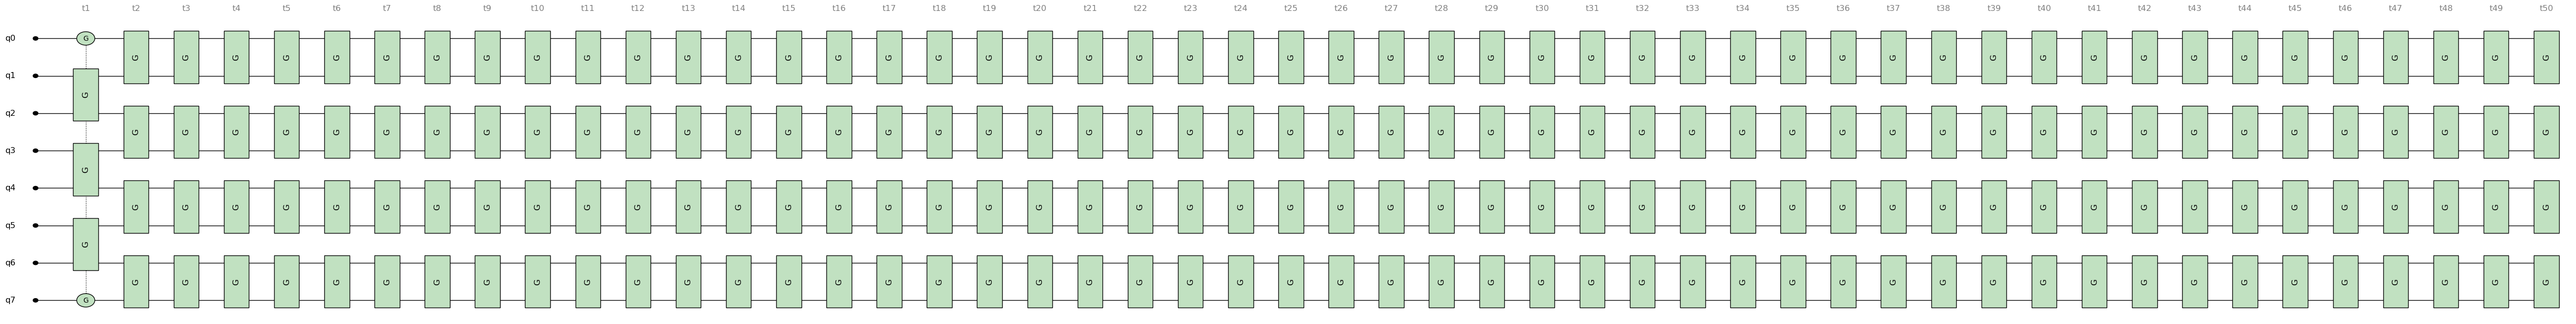

In [88]:
trial_index=5
num_qbits=8
gate_seq = circuit_architecture.generate_gate_sequence_from_NM_pattern(NM_list_skewed[trial_index],num_qbits)
circuit_architecture.draw_quantum_circuit(num_qbits, 50, gate_seq, circuitname='eg.png')

# Get_pops

In [72]:
def get_pops(data, n_qubits, connectivity,update_rule):
    #dimension 0 is each trial
    #dimension 1 is each time step
    #dimension 2 is each qubit
    result = []
    for trial in data[f'{n_qubits} qubits'][f'{connectivity} connectivity']['unitary energy subspace 1']:
        seed = trial.split(' ')[-1]
        dat = dict(data[f'{n_qubits} qubits'][f'{connectivity} connectivity']['unitary energy subspace 1'][f'unitary seed {seed}'][f'ordering seed {update_rule}']['pops'])
        dat = {int(k.split('(')[0]): dat[k] for k in dat}
        dat = np.array([np.array([dat[k][subkey][()] for subkey in sorted(dat[k])]) for k in sorted(dat)])
        result.append(dat)
    return(np.array(result))

In [83]:
pops_NM_skew = get_pops(newdata_skew, 8, "c2_2local", "NonMarkovian")

KeyError: '8 qubits'

# Node evolution

In [ ]:
def plot_node_evolution(data):
    data = np.asarray(data)
    time_steps, num_nodes = data.shape

    # Line plot: evolution of each node
    plt.figure(figsize=(10, 6))
    for i in range(num_nodes):
        plt.plot(range(time_steps), data[:, i], label=f'Node {i}')
    plt.xlabel('Time step')
    plt.ylabel('Value')
    plt.title('Node Evolution Over Time')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Heatmap: time vs node
    plt.figure(figsize=(10, 6))
    plt.imshow(data, aspect='auto', cmap='viridis', origin='lower')
    plt.colorbar(label='Value')
    plt.xlabel('Node')
    plt.ylabel('Time step')
    plt.title('Node Evolution Heatmap')
    plt.tight_layout()
    plt.show()
plot_node_evolution(pops_NM_skew[11][200:300])

# $\tau_z$ statistics

In [ ]:
denom = 15.0
steps = 502
def tz_two_q_dyns_map(pops_trial_index,denom):
    tz = []
    np.array(pops_trial_index)
    for step_index in range(steps):
        tzi =  np.sin(np.pi/denom)*np.sin(np.pi/denom) -2*(pops_trial_index[step_index + 1 ] - np.cos(np.pi / denom)*np.cos(np.pi / denom)* pops_trial_index[step_index])
        tz.append(tzi)
    return tz

In [ ]:
def abs_tz(pops,denom):
    abs_tz=[]
    for step in tz_two_q_dyns_map(pops,denom):
        abs_step = [abs(ele) for ele in step]
        abs_tz.append(abs_step)
    return abs_tz
def CPcond(abs_tz_pops) :
    cp_cond=[]
    for step in abs_tz_pops:
        cp_step = [ele + np.cos(np.pi / denom) * np. cos(np.pi / denom)  for ele in step]
        cp_cond.append(cp_step)
    return cp_cond

def means_stds_of_tz_of_one_sim_index(tz_trial_index):
    mean_stds_list = []
    for step_index in range(steps):
        stds = np.std(tz_trial_index [step_index])
        means = np.mean(tz_trial_index[step_index])
        mean_stds_list.append([means, stds])
    return mean_stds_list

# Connectivity comparison

In [ ]:
def plot_connectivity_comparison(
    pops_dict,
    seed=50,
    denom=15,
    ytherm12=(0.1*11+0.4)/12,  # Default value, adjust as needed
    colors=None,
    dataset_label="comparison",population_titles = ["$R_{1}$", "$R_{2}$", "$R_{3}$", "$R_{4}$", "$R_{5}$"]
):
    """
    Create a 2x5 grid of plots comparing C2 and C4 connectivity for different populations.

    Parameters:
    -----------
    pops_dict : dict
        Dictionary containing population data with keys:
        'time_averaged_c2', 'time_averaged_c4' - lists of 5 populations for time-averaged plots
        'ensemble_c2', 'ensemble_c4' - lists of 5 populations for ensemble-averaged plots
    seed : int
        Seed to use for time-averaged plots
    denom : int
        Denominator value for calculations
    ytherm10 : float
        Thermal value for reference line
    colors : list
        List of colors to use for plotting
    dataset_label : str
        Label to use in saved filenames
    """
    if colors is None:
        colors = ['#5B8FD8', '#FF6F61', '#6DBE45', '#D79F9D', '#7E7B9A','#F0E68C', '#008080', '#C2A2D2', '#D04E00', '#A8E6CF','#FFDAB9', '#B2B09C']

    # Create figure with GridSpec for better control
    fig = plt.figure(figsize=(30, 12))
    gs = gridspec.GridSpec(2, 5, figure=fig, wspace=0.1, hspace=0.4)

    # Row 1: Time-Averaged Plots for different populations (seed=50)
    row1_title = "Time-Averaged Plots (seed=50)"
    time_avg_pops_c2 = pops_dict['time_averaged_c2']
    time_avg_pops_c4 = pops_dict['time_averaged_c4']

    # Function to create time-averaged plot
    def create_time_averaged_plot(ax, pops, pop_idx, conn, title, y_global_min, y_global_max):
        data = time_averaged_one_point_measures_matrix_full_sim(tz_two_q_dyns_map(pops[pop_idx][seed], denom), 30)
        data = np.array(data[10:499])
        num_time_steps = len(data)
        t = np.arange(num_time_steps)
        data_transposed = data.T

        # Use the global min and max values for consistent y-axis scaling
        ax.set_ylim(y_global_min, y_global_max)

        # Set consistent number of y-axis ticks (e.g., 5 ticks)
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))

        ax.axhline(y=(1-2*ytherm12)*(np.sin((np.pi)/denom))**2, color='r', linestyle='--',
                  label=r'$\tau_z^*$'f' = {0.03242}')

        for i, y_values in enumerate(data_transposed):
            color = colors[i % len(colors)]
            ax.plot(t, y_values, label=f'$Q_{{{i+1}}}$', color=color, linewidth=1)

        if pop_idx == 0:
            ax.tick_params(axis='both', which='major', labelsize=14)
        else:
            ax.tick_params(axis='y', which='both', left=False, labelleft=False)
        ax.tick_params(axis='both',labelsize=16)

        ax.set_xlabel(r'$\ell$', fontsize=25)
        if pop_idx==0:
            ax.set_ylabel(r'$\overline{ \tau_{z}}$', fontsize=50)
        ax.set_title(f'{title}', fontsize=35)

        # Only add legend to the first plot in each row to save space
        if pop_idx == 2:
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
                     ncol=13, fontsize=20)

    # Main plotting code
    # First, determine global min/max across all datasets
    y_global_min = float('inf')
    y_global_max = float('-inf')

    for pop_idx in range(5):
        data = time_averaged_one_point_measures_matrix_full_sim(tz_two_q_dyns_map(time_avg_pops_c2[pop_idx][seed], denom), 30)
        data = np.array(data[10:499])
        curr_min = np.min(data)
        curr_max = np.max(data)

        # Add some padding as in your original code
        curr_min = curr_min - 0.35 * abs(curr_min)
        curr_max = curr_max + 0.25 * abs(curr_max)

        y_global_min = min(y_global_min, curr_min)
        y_global_max = max(y_global_max, curr_max)

    # Now create all plots with the same y-axis limits
    for pop_idx in range(5):
        ax1 = fig.add_subplot(gs[0, pop_idx])
        create_time_averaged_plot(ax1, time_avg_pops_c2, pop_idx, "C2", population_titles[pop_idx],
                                 y_global_min, y_global_max)

    plt.savefig(f'tz_time_Averaged_comparison_c2_12)q_{dataset_label}.pdf', format='pdf', bbox_inches='tight')
    plt.show()
colors = ['#5B8FD8', '#FF6F61', '#6DBE45', '#D79F9D', '#7E7B9A','#F0E68C', '#008080', '#C2A2D2', '#D04E00', '#A8E6CF','#FFDAB9', '#B2B09C']

# Prepare your data dictionary
pops_dict = {
    # Time-averaged data (top row)
    'time_averaged_c2': [pops_random_c2_th, pops_greedy_c2_th, pops_landmax_c2_th, pops_strongmax_c2_th,pops_mimic_c2_th],
    'time_averaged_c4': [pops_random_c4_th, pops_greedy_c4_th, pops_landmax_c4_th, pops_strongmax_c4_th,pops_mimic_c4_th],

    # Ensemble-averaged data (bottom row)
    #'ensemble_c2':[pops_random_c2_th, pops_greedy_c2_th, pops_landscape_maximizes_c2_th, pops_strongest_maximizes_c2_th,pops_mimic_c2_th],
    #'ensemble_c4':[pops_random_c4_th, pops_greedy_c4_th, pops_landscape_maximizes_c4_th, pops_strongest_maximizes_c4_th,pops_mimic_c4_th]
    }

y_min=np.min([pops_random_c2_th, pops_greedy_c2_th, pops_landmax_c2_th, pops_strongmax_c2_th,pops_mimic_c2_th])
y_max = np.max([pops_random_c2_th, pops_greedy_c2_th, pops_landmax_c2_th, pops_strongmax_c2_th,pops_mimic_c2_th])
# Call the function with seed=50
plot_connectivity_comparison(
    pops_dict,
    seed=35,
    denom=15,
    ytherm12=ytherm12,  # Adjust this value as needed
    colors=colors,
    dataset_label="Tz_time_ens_avg_12_Q_th",population_titles = ["$R_{1}$", "$R_{2}$", "$R_{3}$", "$R_{4}$", "$R_{5}$"]
)

In [ ]:
def plot_aggregate_density(data, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # Set up colors
    colors =['#5B8FD8', '#FF6F61', '#6DBE45', '#D79F9D', '#7E7B9A','#F0E68C', '#008080', '#C2A2D2', '#D04E00', '#A8E6CF','#FFDAB9', '#B2B09C']

    # For each position
    for pos in range(12):
        # Collect all values for this position across all datasets and trials
        all_position_values = data[:, :, pos].flatten()

        # Calculate the KDE
        x = np.linspace(np.min(all_position_values), np.max(all_position_values), 1000)
        kde = gaussian_kde(all_position_values)

        # Plot the density on the provided axis
        ax.plot(x, kde(x), color=colors[pos], linewidth=2)

        # Optional: Add a small rug plot to show actual data distribution
        #ax.plot(all_position_values, np.zeros_like(all_position_values) - 0.005 * (pos+1),
        #        '|', color=colors[pos], alpha=1, markersize=5)

        ax.tick_params(axis='both',labelsize=28)

    # Add visual enhancements
    #ax.set_title('Aggregate Probability Density of Values Across All Datasets and Trials', fontsize=16)
    ax.set_xlabel(r'$\tau_Z$', fontsize=54)
    ax.set_ylabel('Density', fontsize=55)

    # Add mean line
    if data.sum() / (data.size) != 0:
        mean_value = data.mean()
        ax.axvline(x=mean_value, color='red', linestyle='--')
        ax.text(mean_value, ax.get_ylim()[1]*0.9, r'$\mu$'f': {mean_value:.4f}',
               color='red', fontsize=30)

    return ax

# Histograms grid

In [ ]:
datasets = [
    full_sim_tz(pops_random_c4_th, 15),
    full_sim_tz(pops_greedy_c4_th, 15),
    full_sim_tz(pops_landmax_c4_th, 15),
    full_sim_tz(pops_strongmax_c4_th, 15),
    full_sim_tz(pops_mimic_c4_th, 15),
    full_sim_tz(pops_random_c4_v1, 15),
    full_sim_tz(pops_greedy_c4_v1, 15),
    full_sim_tz(pops_landmax_c4_v1, 15),
    full_sim_tz(pops_strongmax_c4_v1, 15),
    full_sim_tz(pops_mimic_c4_v1, 15),
    full_sim_tz(pops_random_c4_v2, 15),
    full_sim_tz(pops_greedy_c4_v2, 15),
    full_sim_tz(pops_landmax_c4_v2, 15),
    full_sim_tz(pops_strongmax_c4_v2, 15),
    full_sim_tz(pops_mimic_c4_v2, 15),
    full_sim_tz(pops_random_c4_pure, 15),
    full_sim_tz(pops_greedy_c4_pure, 15),
    full_sim_tz(pops_landmax_c4_pure, 15),
    full_sim_tz(pops_strongmax_c4_pure, 15),
    full_sim_tz(pops_mimic_c4_pure, 15)
]

def plot_histograms_grid(datasets, time_range=(300, 499), figsize=(30, 24)):
    """
    Plot histograms with fit curves for multiple datasets in a grid layout.

    Parameters:
    -----------
    datasets : list
        List of datasets, each with shape (n_trials, n_timesteps, n_dimensions)
    time_range : tuple
        Range of time steps to include (start, end)
    figsize : tuple
        Figure size for the plot
    """
    n_datasets = len(datasets)
    start_time, end_time = time_range

    # Define grid layout
    n_rows = 4
    n_cols = 5

    if n_datasets > n_rows * n_cols:
        raise ValueError(f"Can only display {n_rows * n_cols} datasets in the grid, but got {n_datasets}")

    # Define colors for each column
    colors = ['#4169E1', '#DC143C', '#228B22', '#FF8C00', '#8A2BE2']

    # Define markers for each row
    markers = ['o', 'D', '^', 's']  # circle, diamond, triangle, square

    #pick your own
    threshold = 0.04322
    # Create figure with grid of subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()  # Flatten to make indexing easier

    # Find the min and max x values for each row to make x-axes uniform per row
    row_min_x = [float('inf')] * n_rows
    row_max_x = [float('-inf')] * n_rows

    # First pass: find min and max x values for each row
    for i, data in enumerate(datasets):
        if i >= n_rows * n_cols:
            continue

        row_idx = i // n_cols

        # Extract data for the specified time range
        time_slice = slice(start_time, end_time + 1)
        selected_data = data[:, time_slice, :]

        # Flatten the data for histogram
        flat_data = selected_data.reshape(-1)

        # Update min and max for the row
        row_min_x[row_idx] = min(row_min_x[row_idx], np.min(flat_data))
        row_max_x[row_idx] = max(row_max_x[row_idx], np.max(flat_data))
    # Process each dataset
    #DEFINE THESE VALUES!!!!!!
    max_density=[max_th,max_v1,max_v2,max_p]
    for i, data in enumerate(datasets):
        if i >= n_datasets:
            break

        n_trials, n_timesteps, n_dimensions = data.shape

        if n_dimensions != 12:
            raise ValueError(f"Dataset {i+1}: Expected 12 dimensions, but got {n_dimensions}")

        # Extract data for the specified time range
        time_slice = slice(start_time, end_time + 1)
        selected_data = data[:, time_slice, :]

        # Flatten the data for histogram
        flat_data = selected_data.reshape(-1)

        # Get the current subplot
        ax = axes[i]

        # Determine column index for color and row index for marker
        col_idx = i % n_cols
        row_idx = i // n_cols
        hist_color = colors[col_idx]

        # Create legend label based on row (CS1, CS2, CS3, CSP)
        if row_idx == 3:
            legend_label = f'CSP'
        else:
            legend_label = f'CS{row_idx+1}'

        # Create histogram with normalized y-axis (0-100)
        hist_values, bin_edges, patches = ax.hist(flat_data, bins=50, density=True,
                                          alpha=0.4, color=hist_color,
                                          label=legend_label)

        # Scale the y-axis values to range from 0 to 100
       # max_density = np.max([np.float64(48.98734484454637), np.float64(99.47113439635753), np.float64(73.97348246976217), np.float64(85.57198150664834), np.float64(111.69010767074764), np.float64(46.33570305988926), np.float64(48.9320488885684), np.float64(43.50713108942431), np.float64(35.64586632164801), np.float64(56.48715115034697), np.float64(46.30078458090764), np.float64(32.83104206837531), np.float64(32.73852054189013), np.float64(34.0456856172911), np.float64(52.345517352909724), np.float64(14.307420373054745), np.float64(25.980772528956667), np.float64(15.575665982851712), np.float64(18.41183738390349), np.float64(18.624787264412724)])
        #max_hist.append(max_density)
        #if max_density > 0:  # Avoid division by zero
            #for rect, height in zip(patches, hist_values):
                #rect.set_height(height / max_density * 100)

        # Set y-axis limits to 0-100 for all plots
        #if i in range(0,5):
        #    ax.set_ylim(0, max_th+5)
        #if i in range(5,10):
        #    ax.set_ylim(0, max_v1+5)
        #if i in range(10,15):
        #    ax.set_ylim(0, max_v2+5)
        #if i in range(15,20):
        #    ax.set_ylim(0, max_p+5)

        # Set uniform x-axis for all plots in this row
        #ax.set_xlim(row_min_x[row_idx], row_max_x[row_idx])

        # Calculate bin centers for curve fitting
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Fit normal distribution
        mu, sigma = stats.norm.fit(flat_data)
        kurtosis = stats.kurtosis(flat_data)  # This calculates the excess kurtosis
        skew = stats.skew(flat_data)  # This calculates the excess kurtosis
        actual_kurtosis = stats.kurtosis(flat_data) + 3
        prob_above_threshold = np.mean(np.abs(flat_data) > threshold)
        print(sigma)

        # Plot the fit curve
        x = np.linspace(row_min_x[row_idx], row_max_x[row_idx], 100)
        y = stats.norm.pdf(x, mu, sigma)

        # Scale the y values of the normal curve to the 0-100 range


        ax.plot(x, y, 'r-', linewidth=2, label=f'μ={mu:.3f}, σ={sigma:.3f}')

        # Add a point with the appropriate marker for the legend
        # This is a dummy point just for the marker in the legend
        ax.scatter([], [], color=hist_color, marker=markers[row_idx], s=100, label='_nolegend_')

        # Calculate additional statistics
        median = np.median(flat_data)
        min_val = np.min(flat_data)
        max_val = np.max(flat_data)
        p25 = np.percentile(flat_data, 25)
        p75 = np.percentile(flat_data, 75)

        # Add text box with statistics - fixed the LaTeX formatting
        stats_text = (f"Mean: {mu:.3f}\n"
                      f"Std Dev: {sigma:.3f}\n"
                      f"Kurtosis: {kurtosis:.3f}\n"
                      f"Skew: {skew:.3f}\n"
                      f"P($\\tau_{{z;NCP}}$): {prob_above_threshold:.3f}")

        # Add stats text box
        ax.text(0.95, 0.95, stats_text,
                transform=ax.transAxes,
                fontsize=18,
                verticalalignment='top',
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.2))

        # Add vertical lines for mean and median
        ax.axvline(x=mu, color='red', linestyle='--', alpha=0.6)
        ax.axvline(x=0.04322, color='black', linestyle='--', alpha=1)

        # Set titles and labels
        if i<5:
            ax.set_title(f'R{i+1}', fontsize=28)

        # Only add x-axis label to bottom row
        if i >= n_datasets - n_cols:
            ax.set_xlabel(r'$\tau_z$', fontsize=28)

        # Only add y-axis label to leftmost column
        if i % n_cols == 0:
            ax.set_ylabel('Density (%)', fontsize=25)

        # Create custom legend with marker and label
        handles, labels = ax.get_legend_handles_labels()
        # Only keep the first handle (histogram) and its label
        legend_handle = handles[0]
        # Modify the legend handle to use the appropriate marker
        from matplotlib.lines import Line2D
        custom_handle = Line2D([0], [0], marker=markers[row_idx], color=hist_color,
                             markersize=10, linestyle='None')

        ax.legend(handles=[custom_handle, handles[1]],
                  labels=[legend_label, labels[1]],
                  loc='upper left', fontsize=15)

        # Add grid
        ax.grid(True, linestyle='--', alpha=0.5)

    # Hide any unused subplots
    for j in range(n_datasets, n_rows * n_cols):
        axes[j].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust layout
    print(max_density)
    return fig

# Assuming your dataset is a list of 20 numpy arrays, each with shape (100, 500, 12)
fig = plot_histograms_grid(datasets)
plt.savefig('tz_histogram_per_rule_per_IC_ens_avg_c4.png', dpi=300, bbox_inches='tight')
plt.show()